## **Implementação de uma rede neural LSTM**

### *Objetivo:* 

Aplicar conceitos de Redes Neurais Recorrentes do tipo LSTM no desenvolvimento de um modelo de *deep learning* para dados sequenciais, como séries temporais, dados financeiros, sensores, consumo, clima, tráfego, texto ou outro conjunto adequado. Preparar o *dataset*, construir janelas temporais quando necessário. Treinar uma LSTM base e realizar um ajuste de hiperparâmetros. Analisar o impacto das escolhas no desempenho do modelo.

### *1. Escolha e Preparação do Dataset*

O dataset que escolhemos para realizar esta atividade foi o [Metro Interstate Traffic Volume](https://archive.ics.uci.edu/dataset/492/metro+interstate+traffic+volume) da *UC Irvine Machine Learning Repository*. A escolha proveio do fato do conjunto de dados já relativamente conhecido para a construção de LSTMs, por se tratar de uma série temporal com uma variável alvo clara. 

A UCI informa que o dataset contém volume horário de tráfego na rodovia I-94, em Minneapolis–St Paul, entre 2012 e 2018, incluindo clima e feriados. A variável alvo é `traffic_volume`; as entradas podem ser histórico de tráfego, temperatura, chuva, neve, nuvens, descrição do clima, hora, dia da semana ou feriado. Logo, vamos tentar prever o tráfego de um intervalo de 24 horas a partir do conjunto de dados fornecidos.




In [1]:
pip install ucimlrepo

In [2]:
# importando o dataset
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
metro_interstate_traffic_volume = fetch_ucirepo(id=492) 
  
# data (as pandas dataframes) 
X = metro_interstate_traffic_volume.data.features 
y = metro_interstate_traffic_volume.data.targets 
  
# metadata 
print(metro_interstate_traffic_volume.metadata) 
  
# variable information 
print(metro_interstate_traffic_volume.variables) 

{'uci_id': 492, 'name': 'Metro Interstate Traffic Volume', 'repository_url': 'https://archive.ics.uci.edu/dataset/492/metro+interstate+traffic+volume', 'data_url': 'https://archive.ics.uci.edu/static/public/492/data.csv', 'abstract': 'Hourly Minneapolis-St Paul, MN traffic volume for westbound I-94. Includes weather and holiday features from 2012-2018.', 'area': 'Other', 'tasks': ['Regression'], 'characteristics': ['Multivariate', 'Sequential', 'Time-Series'], 'num_instances': 48204, 'num_features': 8, 'feature_types': ['Integer', 'Real'], 'demographics': [], 'target_col': ['traffic_volume'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2019, 'last_updated': 'Fri Mar 15 2024', 'dataset_doi': '10.24432/C5X60B', 'creators': ['John Hogue'], 'intro_paper': None, 'additional_info': {'summary': 'Hourly Interstate 94 Westbound traffic volume for MN DoT ATR station 301, roughly midway between Minneapolis and St Paul, MN. Hourly weath

*1.1 Juntando os dados em um só dataframe*

In [ ]:
import pandas as pd
import numpy as np

df = X.copy()
df["traffic_volume"] = y

df.head()

,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume
0,NaN,288.28,0.0,0.0,40,Clouds,scattered clouds,2012-10-02 09:00:00,5545
1,NaN,289.36,0.0,0.0,75,Clouds,broken clouds,2012-10-02 10:00:00,4516
2,NaN,289.58,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 11:00:00,4767
3,NaN,290.13,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 12:00:00,5026
4,NaN,291.14,0.0,0.0,75,Clouds,broken clouds,2012-10-02 13:00:00,4918


*1.2 Analisando variáveis*

In [ ]:
df.shape

(48204, 9)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48204 entries, 0 to 48203
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   holiday              61 non-null     object 
 1   temp                 48204 non-null  float64
 2   rain_1h              48204 non-null  float64
 3   snow_1h              48204 non-null  float64
 4   clouds_all           48204 non-null  int64  
 5   weather_main         48204 non-null  object 
 6   weather_description  48204 non-null  object 
 7   date_time            48204 non-null  object 
 8   traffic_volume       48204 non-null  int64  
dtypes: float64(3), int64(2), object(4)
memory usage: 3.3+ MB


In [ ]:
df.describe()

,temp,rain_1h,snow_1h,clouds_all,traffic_volume
count,48204.000000,48204.000000,48204.000000,48204.000000,48204.000000
mean,281.205870,0.334264,0.000222,49.362231,3259.818355
std,13.338232,44.789133,0.008168,39.015750,1986.860670
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,272.160000,0.000000,0.000000,1.000000,1193.000000
50%,282.450000,0.000000,0.000000,64.000000,3380.000000
75%,291.806000,0.000000,0.000000,90.000000,4933.000000
max,310.070000,9831.300000,0.510000,100.000000,7280.000000


À primeira vista, não há valores ausentes no dataset, o que é ótimo. Mas já vejo que date_time está como tipo `object`, ou seja, texto puro, logo, vamos convertê-la para podermos analisar a sequência temporal. Além disso, apesar de parecer ter muitos valores ausentes na coluna `holiday`, na verdade ela possui o nome dos feriados e `NaN` quando um dia não é feriado, mas vamos transformar isso em 0 para dias comuns e 1 para feriados para simplificar.

*1.3 Convertendo colunas*

In [7]:
df["date_time"] = pd.to_datetime(df["date_time"])
df = df.sort_values("date_time").reset_index(drop=True)

In [ ]:
df.head()

,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume
0,NaN,288.28,0.0,0.0,40,Clouds,scattered clouds,2012-10-02 09:00:00,5545
1,NaN,289.36,0.0,0.0,75,Clouds,broken clouds,2012-10-02 10:00:00,4516
2,NaN,289.58,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 11:00:00,4767
3,NaN,290.13,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 12:00:00,5026
4,NaN,291.14,0.0,0.0,75,Clouds,broken clouds,2012-10-02 13:00:00,4918


In [ ]:
print(df["date_time"].min(), df["date_time"].max())


2012-10-02 09:00:00 2018-09-30 23:00:00


Intervalo temporal está correto, confirmando que organizamos o dataframe de acordo com a data e convertemos a coluna corretamente.

In [10]:
df["holiday"] = df["holiday"].astype("string")

holiday_series = pd.Series(df["holiday"])

for index, item in holiday_series.items():
    if pd.isna(item):
        holiday_series[index] = '0'
    elif type(item) is type("string"):
        holiday_series[index] = '1'

holiday_series.value_counts()
## Tipicamente é dito que não é uma boa prática iterar por séries do pandas e que se você está fazendo isso,
## provavelmente está fazendo algo errado. Mas, não consegui pensar em outro jeito de fazer que não fosse trabalhoso.
## Poderia ter feito um map com o nome de cada feriado, mas seria chato demais (┬┬﹏┬┬)

,count
holiday,
0,48143
1,61


In [11]:
df["holiday"] = holiday_series.astype(int)
df.rename(columns={"holiday": "is_holiday"}, inplace=True)
df

,is_holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume
0,0,288.28,0.0,0.0,40,Clouds,scattered clouds,2012-10-02 09:00:00,5545
1,0,289.36,0.0,0.0,75,Clouds,broken clouds,2012-10-02 10:00:00,4516
2,0,289.58,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 11:00:00,4767
3,0,290.13,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 12:00:00,5026
4,0,291.14,0.0,0.0,75,Clouds,broken clouds,2012-10-02 13:00:00,4918
...,...,...,...,...,...,...,...,...,...
48199,0,283.45,0.0,0.0,75,Clouds,broken clouds,2018-09-30 19:00:00,3543
48200,0,282.76,0.0,0.0,90,Clouds,overcast clouds,2018-09-30 20:00:00,2781
48201,0,282.73,0.0,0.0,90,Thunderstorm,proximity thunderstorm,2018-09-30 21:00:00,2159
48202,0,282.09,0.0,0.0,90,Clouds,overcast clouds,2018-09-30 22:00:00,1450


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48204 entries, 0 to 48203
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   is_holiday           48204 non-null  int64         
 1   temp                 48204 non-null  float64       
 2   rain_1h              48204 non-null  float64       
 3   snow_1h              48204 non-null  float64       
 4   clouds_all           48204 non-null  int64         
 5   weather_main         48204 non-null  object        
 6   weather_description  48204 non-null  object        
 7   date_time            48204 non-null  datetime64[ns]
 8   traffic_volume       48204 non-null  int64         
dtypes: datetime64[ns](1), float64(3), int64(3), object(2)
memory usage: 3.3+ MB


Transformação bem-sucedida!

Para finalizar o tratamento de dados, vamos verificar se não há duplicatas.

*1.4 Tratamento de duplicatas*

In [ ]:
print(df.duplicated().sum(), "\n", df.isna().sum())

17 
 is_holiday             0
temp                   0
rain_1h                0
snow_1h                0
clouds_all             0
weather_main           0
weather_description    0
date_time              0
traffic_volume         0
dtype: int64


In [14]:
df.loc[df.duplicated()]

,is_holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume
18697,0,286.290,0.0,0.0,1,Clear,sky is clear,2015-09-30 19:00:00,3679
23851,0,289.060,0.0,0.0,90,Clouds,overcast clouds,2016-06-01 10:00:00,4831
26784,0,289.775,0.0,0.0,56,Clouds,broken clouds,2016-09-21 15:00:00,5365
26980,0,287.860,0.0,0.0,0,Clear,Sky is Clear,2016-09-29 19:00:00,3435
27171,0,279.287,0.0,0.0,56,Clouds,broken clouds,2016-10-07 18:00:00,4642
28879,0,267.890,0.0,0.0,90,Snow,light snow,2016-12-06 18:00:00,4520
29268,0,254.220,0.0,0.0,1,Clear,sky is clear,2016-12-19 00:00:00,420
34711,0,295.010,0.0,0.0,40,Clouds,scattered clouds,2017-06-21 11:00:00,4808
34967,0,292.840,0.0,0.0,1,Clear,sky is clear,2017-06-30 10:00:00,4638
34969,0,294.520,0.0,0.0,1,Clear,sky is clear,2017-06-30 11:00:00,4725


In [ ]:
df.loc[df["date_time"] == pd.to_datetime("2018-09-29 19:00:00")]

,is_holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume
48172,0,280.68,0.0,0.0,90,Clouds,overcast clouds,2018-09-29 19:00:00,3818
48173,0,280.68,0.0,0.0,90,Clouds,overcast clouds,2018-09-29 19:00:00,3818


In [ ]:
## Aparentemente existem alguns duplicatas, então vou simplesmente removê-los já que não há sentido para uma análise temporal mantê-los.

df.drop_duplicates(inplace=True)
df.duplicated().sum()

np.int64(0)

Antes de criar as janelas da LSTM, ainda falta um detalhe importante: verificar se ha mais de uma linha para o mesmo horario. Em series temporais, isso atrapalha porque a rede espera uma sequencia ordenada, com um registro por passo de tempo.

In [ ]:
df["date_time"].duplicated().sum()

np.int64(7612)

Como existem horários repetidos, vou manter uma única linha por `date_time`. Isso pode ter ocorrido por climas semelhantes terem sido medidos ao mesmo tempo, mas não deve afetar a rede. Para variáveis numéricas, uso a média; para clima em texto, uso a moda; para feriado, mantenho 1 se qualquer linha daquele horario for feriado.

In [18]:
def moda_primeiro_valor(serie):
    return serie.mode().iloc[0]


df = (
    df.sort_values("date_time")
    .groupby("date_time", as_index=False)
    .agg({
        "is_holiday": "max",
        "temp": "mean",
        "rain_1h": "mean",
        "snow_1h": "mean",
        "clouds_all": "mean",
        "weather_main": moda_primeiro_valor,
        "weather_description": moda_primeiro_valor,
        "traffic_volume": "mean",
    })
)

df["traffic_volume"] = df["traffic_volume"].round().astype(int)
df.shape

(40575, 9)

In [ ]:
df["date_time"].diff().value_counts().head()

,count
date_time,
0 days 01:00:00,37986
0 days 02:00:00,2192
0 days 03:00:00,201
0 days 04:00:00,59
0 days 05:00:00,33


Agora a base está mais adequada para a rede, sem valores ausentes, sem duplicatas exatas e sem horários repetidos numa mesma data. 

Já que o dataframe utiliza o tipo `datetime` do pandas, precisamos quebrar o tempo em colunas separadas para que a rede seja capaz de entender separadamente os padrões de hora, dia da semana, mês, etc. 

In [ ]:
df["year"] = df["date_time"].dt.year
df["month"] = df["date_time"].dt.month
df["day"] = df["date_time"].dt.day
df["hour"] = df["date_time"].dt.hour
df["day_of_week"] = df["date_time"].dt.dayofweek  # segunda=0, domingo=6
df["is_weekend"] = df["day_of_week"].isin([5, 6]).astype(int)

df.head()

,date_time,is_holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,traffic_volume,year,month,day,hour,day_of_week,is_weekend
0,2012-10-02 09:00:00,0,288.28,0.0,0.0,40.0,Clouds,scattered clouds,5545,2012,10,2,9,1,0
1,2012-10-02 10:00:00,0,289.36,0.0,0.0,75.0,Clouds,broken clouds,4516,2012,10,2,10,1,0
2,2012-10-02 11:00:00,0,289.58,0.0,0.0,90.0,Clouds,overcast clouds,4767,2012,10,2,11,1,0
3,2012-10-02 12:00:00,0,290.13,0.0,0.0,90.0,Clouds,overcast clouds,5026,2012,10,2,12,1,0
4,2012-10-02 13:00:00,0,291.14,0.0,0.0,75.0,Clouds,broken clouds,4918,2012,10,2,13,1,0


No notebook de exemplo de LSTM que vimos duranta a aula, as métricas de preço são normalizadas, o que funciona, mas aqui não podemos simplesmente normalizar por se tratar de uma escala temporal. Por exemplo, os dias são cíclicos, 23h é próximo de 00h, mas caso façamos a normalização, a rede vai entender que 23h é muito longe de 00h. Portanto, precisamos usar uma escala **cíclica**, ou seja, utilizamos seno e cosseno, já que variam entre 0 e 1.

In [ ]:
## 2πr = comprimento da circunferência de raio cuja hora vai definir
## / 24 = para definir o intervalo de 24h
df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)

df["days_of_week_sin"] = np.sin(2 * np.pi * df["day_of_week"] / 7)
df["days_of_week_cos"] = np.cos(2 * np.pi * df["day_of_week"] / 7)

df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)

df.head()

,date_time,is_holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,traffic_volume,year,...,day,hour,day_of_week,is_weekend,hour_sin,hour_cos,days_of_week_sin,days_of_week_cos,month_sin,month_cos
0,2012-10-02 09:00:00,0,288.28,0.0,0.0,40.0,Clouds,scattered clouds,5545,2012,...,2,9,1,0,7.071068e-01,-0.707107,0.781831,0.62349,-0.866025,0.5
1,2012-10-02 10:00:00,0,289.36,0.0,0.0,75.0,Clouds,broken clouds,4516,2012,...,2,10,1,0,5.000000e-01,-0.866025,0.781831,0.62349,-0.866025,0.5
2,2012-10-02 11:00:00,0,289.58,0.0,0.0,90.0,Clouds,overcast clouds,4767,2012,...,2,11,1,0,2.588190e-01,-0.965926,0.781831,0.62349,-0.866025,0.5
3,2012-10-02 12:00:00,0,290.13,0.0,0.0,90.0,Clouds,overcast clouds,5026,2012,...,2,12,1,0,1.224647e-16,-1.000000,0.781831,0.62349,-0.866025,0.5
4,2012-10-02 13:00:00,0,291.14,0.0,0.0,75.0,Clouds,broken clouds,4918,2012,...,2,13,1,0,-2.588190e-01,-0.965926,0.781831,0.62349,-0.866025,0.5


### *2. LSTM base com PyTorch*

Nesta etapa, vamos criar uma LSTM simples antes de mexer em hiperparâmetros. A ideia é usar as últimas 24 observações para prever o `traffic_volume` da próxima hora.

Como a LSTM recebe números, precisamos transformar as colunas categóricas em colunas binárias e escalar as variáveis numéricas. A escala será ajustada somente no treino para evitar data leaking durante a validação.

OBS: Decidi ir um pouco além e tentei fazer uma LSTM multivariada já que o dataset possui vários campos além do horário que podem influenciar o `traffic_volume`.

In [22]:
pip install torch scikit-learn matplotlib

In [ ]:
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt

## Na hora de selecionar o kernel do collab sugiro colocar uma GPU, com a CPU demora mais de 10 MINUTOS enquanto com GPU e CUDA da NVIDEA é questão de 1 ou 2 minutos  
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DEVICE

'cuda'

Para uma LSTM multivariada, a entrada precisa ter várias colunas obviamente. Usamos o histórico do próprio tráfego, as variáveis climáticas, feriado/fim de semana e os ciclos de hora, dia da semana e mês. Não usamos `date_time` por motivos já citados antes.

In [ ]:
feature_cols = [
    "traffic_volume",
    "temp",
    "rain_1h",
    "snow_1h",
    "clouds_all",
    "is_holiday",
    "is_weekend",
    "hour_sin",
    "hour_cos",
    "days_of_week_sin",
    "days_of_week_cos",
    "month_sin",
    "month_cos",
]

model_df = df[feature_cols + ["weather_main", "weather_description"]].copy()

# Usamos o get_dummies do pandas que é semelhante a um one-hot encoding
# O método analisa uma coluna categórica e cria uma nova coluna para cada categoria única.
# Ele preenche essas novas colunas com 1 se a categoria original pertencer àquela linha, e 0 se não.

model_df = pd.get_dummies(
    model_df,
    columns=["weather_main", "weather_description"],
    dtype=float,
)

model_df.head()

,traffic_volume,temp,rain_1h,snow_1h,clouds_all,is_holiday,is_weekend,hour_sin,hour_cos,days_of_week_sin,...,weather_description_scattered clouds,weather_description_sky is clear,weather_description_smoke,weather_description_snow,weather_description_thunderstorm,weather_description_thunderstorm with heavy rain,weather_description_thunderstorm with light drizzle,weather_description_thunderstorm with light rain,weather_description_thunderstorm with rain,weather_description_very heavy rain
0,5545,288.28,0.0,0.0,40.0,0,0,7.071068e-01,-0.707107,0.781831,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,4516,289.36,0.0,0.0,75.0,0,0,5.000000e-01,-0.866025,0.781831,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,4767,289.58,0.0,0.0,90.0,0,0,2.588190e-01,-0.965926,0.781831,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,5026,290.13,0.0,0.0,90.0,0,0,1.224647e-16,-1.000000,0.781831,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,4918,291.14,0.0,0.0,75.0,0,0,-2.588190e-01,-0.965926,0.781831,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


A divisão treino/teste/valid. precisa respeitar o tempo. Por isso, não usamos `train_test_split` com embaralhamento: o treino fica no começo da série, a validação no meio e o teste no final.

In [ ]:
train_end = int(len(model_df) * 0.70)
# 70% para treino
val_end = int(len(model_df) * 0.85)
# 15% para validação
# 15% para teste
target_col = "traffic_volume"

train_df = model_df.iloc[:train_end]
val_df = model_df.iloc[train_end:val_end]
test_df = model_df.iloc[val_end:]

train_df.shape, val_df.shape, test_df.shape

((28402, 56), (6086, 56), (6087, 56))

In [ ]:
feature_scaler = StandardScaler()
target_scaler = StandardScaler()

X_train_scaled = feature_scaler.fit_transform(train_df) # fit APENAS no treino
X_val_scaled = feature_scaler.transform(val_df)
X_test_scaled = feature_scaler.transform(test_df)

y_train_scaled = target_scaler.fit_transform(train_df[[target_col]]).ravel() # fit APENAS no treino e fazemos um ravel para transformar tudo num arrayzão, o que facilita na hora da rede "checar o gabarito" por assim dizer
y_val_scaled = target_scaler.transform(val_df[[target_col]]).ravel()
y_test_scaled = target_scaler.transform(test_df[[target_col]]).ravel()

Agora vem a parte mais importante para uma LSTM: transformar a tabela em janelas. Cada `X` terá o formato `(24, num_de_variaveis)`, e cada `y` será o tráfego da hora seguinte. Ou seja, é um neurônio que se duplica 24 vezes para prever a vigésima quinta com memória a longo e curto prazo, uma rede LSTM!

In [ ]:
def criar_janelas(features, target, window_size):
    X, y = [], []

    for i in range(window_size, len(features)):
        X.append(features[i - window_size:i])
        y.append(target[i])
    
    # Em suma, converte a lista de janelas em array numérico no formato esperado pela LSTM.
    # Esse reshape(-1, 1) é importante porque o modelo também retorna previsões nesse formato, uma previsão por linha. 
    # O -1 significa “calcule automaticamente quantas linhas são necessárias”.
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32).reshape(-1, 1)


window_size = 24

X_train, y_train = criar_janelas(X_train_scaled, y_train_scaled, window_size)

X_val_context = np.vstack([X_train_scaled[-window_size:], X_val_scaled])
y_val_context = np.concatenate([y_train_scaled[-window_size:], y_val_scaled])
X_val, y_val = criar_janelas(X_val_context, y_val_context, window_size)

X_test_context = np.vstack([X_val_scaled[-window_size:], X_test_scaled])
y_test_context = np.concatenate([y_val_scaled[-window_size:], y_test_scaled])
X_test, y_test = criar_janelas(X_test_context, y_test_context, window_size)

X_train.shape, y_train.shape, X_val.shape, y_val.shape, X_test.shape, y_test.shape

((28378, 24, 56),
 (28378, 1),
 (6086, 24, 56),
 (6086, 1),
 (6087, 24, 56),
 (6087, 1))

No PyTorch, o `Dataset` guarda os dados e o `DataLoader` entrega pequenos lotes para o treinamento. A LSTM continua vendo a ordem dentro de cada janela; o `shuffle=True` so muda a ordem dos lotes de treino.

In [ ]:
class TrafficDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.from_numpy(X)
        self.y = torch.from_numpy(y)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


batch_size = 64

train_loader = DataLoader(TrafficDataset(X_train, y_train), batch_size=batch_size, shuffle=True)
val_loader = DataLoader(TrafficDataset(X_val, y_val), batch_size=batch_size, shuffle=False)
test_loader = DataLoader(TrafficDataset(X_test, y_test), batch_size=batch_size, shuffle=False)

A classe abaixo é a rede em si. O `nn.LSTM` lê a sequência; depois pegamos apenas a saída do último passo da janela e passamos por uma camada linear (perceptron) para gerar uma previsão numérica.

In [29]:
class LSTMBase(nn.Module):
    def __init__(self, n_features, hidden_size=64, num_layers=1):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=n_features,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
        )
        self.linear = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :]
        return self.linear(out)


model = LSTMBase(n_features=X_train.shape[2]).to(DEVICE)
model

LSTMBase(
  (lstm): LSTM(56, 64, batch_first=True)
  (linear): Linear(in_features=64, out_features=1, bias=True)
)

Para a LSTM base, usamos uma configuração fixa e simples com erro quadrático médio como função de perda para penalizar ainda mais erros grandes e Adam como otimizador por ser padrão e por tender a ser mais eficiente em conjuntos de dados pequenos/médios. Depois, na etapa de hiperparâmetros, podemos testar tamanho da janela, número de camadas, neurônios, taxa de aprendizado e tamanho do lote.

In [ ]:
loss_fn = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

def calcular_loss(model, loader):
    model.eval()
    losses = []

# with torch.no_grad():
# Isso significa: “execute o código abaixo sem guardar informações para backpropagation”.
# Durante o treino, o PyTorch precisa guardar operações para depois calcular os gradientes e atualizar os pesos. Mas na validação/teste/previsão, 
# só queremos medir o resultado do modelo, não treiná-lo. Então torch.no_grad() para economizar memória e tempo.
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(DEVICE)
            y_batch = y_batch.to(DEVICE)
            pred = model(X_batch)
            losses.append(loss_fn(pred, y_batch).item())

    return np.mean(losses)

In [31]:
epochs = 20
history = {"train_loss": [], "val_loss": []}

for epoch in range(epochs):
    model.train()
    train_losses = []

    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(DEVICE)
        y_batch = y_batch.to(DEVICE)

        optimizer.zero_grad()
        pred = model(X_batch)
        loss = loss_fn(pred, y_batch)
        loss.backward()
        optimizer.step()

        train_losses.append(loss.item())

    train_loss = np.mean(train_losses)
    val_loss = calcular_loss(model, val_loader)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)

    print(f"Epoch {epoch + 1:02d}/{epochs} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f}")

Epoch 01/20 | train_loss=0.2045 | val_loss=0.0592
Epoch 02/20 | train_loss=0.0757 | val_loss=0.0388
Epoch 03/20 | train_loss=0.0630 | val_loss=0.0351
Epoch 04/20 | train_loss=0.0570 | val_loss=0.0351
Epoch 05/20 | train_loss=0.0532 | val_loss=0.0318
Epoch 06/20 | train_loss=0.0493 | val_loss=0.0300
Epoch 07/20 | train_loss=0.0469 | val_loss=0.0283
Epoch 08/20 | train_loss=0.0443 | val_loss=0.0285
Epoch 09/20 | train_loss=0.0423 | val_loss=0.0296
Epoch 10/20 | train_loss=0.0407 | val_loss=0.0280
Epoch 11/20 | train_loss=0.0387 | val_loss=0.0270
Epoch 12/20 | train_loss=0.0370 | val_loss=0.0272
Epoch 13/20 | train_loss=0.0355 | val_loss=0.0259
Epoch 14/20 | train_loss=0.0344 | val_loss=0.0272
Epoch 15/20 | train_loss=0.0333 | val_loss=0.0303
Epoch 16/20 | train_loss=0.0318 | val_loss=0.0289
Epoch 17/20 | train_loss=0.0308 | val_loss=0.0291
Epoch 18/20 | train_loss=0.0298 | val_loss=0.0259
Epoch 19/20 | train_loss=0.0283 | val_loss=0.0279
Epoch 20/20 | train_loss=0.0282 | val_loss=0.0285


Fazemos uma plotagem rápida para ver como foi a curva de perda

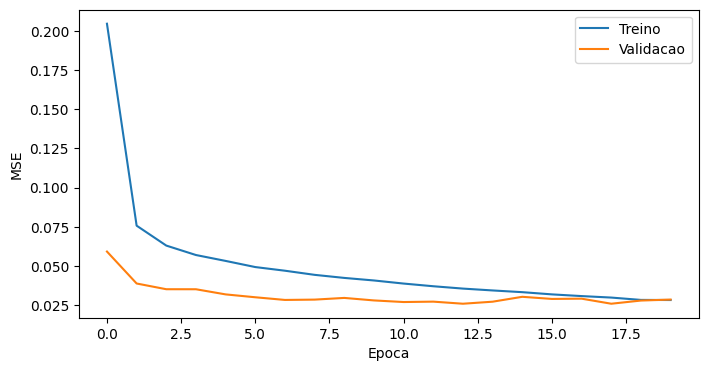

In [32]:
plt.figure(figsize=(8, 4))
plt.plot(history["train_loss"], label="Treino")
plt.plot(history["val_loss"], label="Validacao")
plt.xlabel("Epoca")
plt.ylabel("MSE")
plt.legend()
plt.show()

Pelas curvas de erro, a rede apresentou um bom desempenho geral. A perda de treino diminui de forma consistente ao longo das épocas, enquanto a perda de validação também permanece baixa e relativamente estável. Como as duas curvas ficam próximas e a validação se mantém, não há sinais claros de overfitting. Também não parece haver underfitting, pois o erro cai bem e o modelo consegue aprender o padrão temporal dos dados.

Por fim, voltamos as previsões para a escala original de veículos por hora pois assim as métricas ficam mais fáceis de interpretar.

In [33]:
def prever(model, loader):
    model.eval()
    preds, reais = [], []

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(DEVICE)
            pred = model(X_batch).cpu().numpy()
            preds.append(pred)
            reais.append(y_batch.numpy())

    return np.vstack(preds), np.vstack(reais)


pred_scaled, y_scaled = prever(model, test_loader)

pred = target_scaler.inverse_transform(pred_scaled)
y_real = target_scaler.inverse_transform(y_scaled)

mae = mean_absolute_error(y_real, pred)
rmse = mean_squared_error(y_real, pred) ** 0.5

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")

MAE: 203.67
RMSE: 303.67


In [34]:
resultado = pd.DataFrame({
    "real": y_real.ravel(),
    "previsto": pred.ravel(),
})

resultado.head()

,real,previsto
0,5810.0,5937.846680
1,6305.0,6294.169434
2,5657.0,5889.611816
3,4503.0,4564.388184
4,3516.0,3411.963623


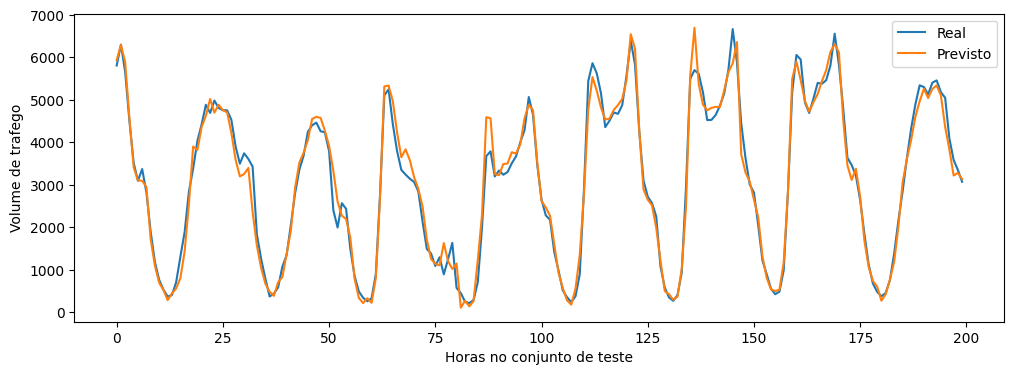

In [35]:
plt.figure(figsize=(12, 4))
plt.plot(resultado["real"].iloc[:200].values, label="Real")
plt.plot(resultado["previsto"].iloc[:200].values, label="Previsto")
plt.xlabel("Horas no conjunto de teste")
plt.ylabel("Volume de trafego")
plt.legend()
plt.show()